In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 0. Load the dataset
df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\OIBSIP\Task_7\creditcard.csv\creditcard.csv')

In [4]:
# 1. Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum())

--- Missing Values ---
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [9]:
# 2. Check the class distribution of the 'Class' target column
print("--- Transaction Count ---")
print(df['Class'].value_counts())

--- Transaction Count ---
Class
0    284315
1       492
Name: count, dtype: int64


In [10]:
# 3. Calculate the exact percentage of fraud
fraud_pct = (df['Class'].value_counts()[1] / len(df)) * 100
print(f"\nPercentage of Fraudulent Transactions: {fraud_pct:.4f}%")


Percentage of Fraudulent Transactions: 0.1727%


C:\Users\ajasl\AppData\Local\Temp\ipykernel_16084\1328596013.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette='Set1')


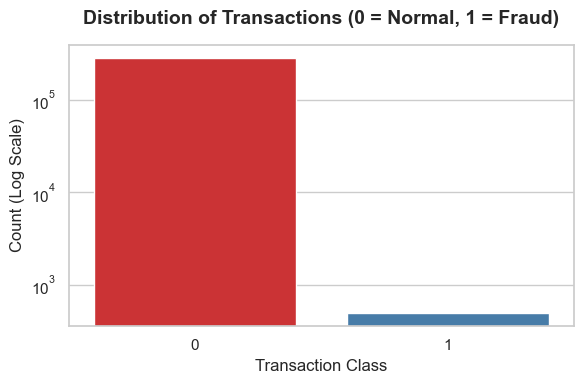

In [11]:
# 4. Visualize the extreme class imbalance
plt.figure(figsize=(6, 4))
sns.set_theme(style="whitegrid")

# Create the countplot
ax = sns.countplot(x='Class', data=df, palette='Set1')
plt.title('Distribution of Transactions (0 = Normal, 1 = Fraud)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Transaction Class', fontsize=12)
plt.ylabel('Count (Log Scale)', fontsize=12)

# Set the y-axis to a logarithmic scale so the tiny fraud bar is visible
plt.yscale('log')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [13]:
# 1. Separate fraudulent and normal transactions
normal = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

In [14]:
# 2. Balance the dataset using Undersampling (match normal count to fraud count)
normal_sample = normal.sample(n=len(fraud), random_state=42)
balanced_df = pd.concat([normal_sample, fraud], axis=0)

In [15]:
# 3. Split the new balanced dataset into Features (X) and Target (y)
X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']

In [16]:
# 4. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# 5. Train a Logistic Regression model
print("Training the model... 🏃‍♂️💨")
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

Training the model... 🏃‍♂️💨


C:\Users\ajasl\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
# 6. Make predictions on the testing set
predictions = model.predict(X_test)

In [19]:
# 7. Evaluate using Precision, Recall, and F1-Score
print("\n--- Model Evaluation (Classification Report) ---")
print(classification_report(y_test, predictions))


--- Model Evaluation (Classification Report) ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        99
           1       0.97      0.89      0.93        98

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197



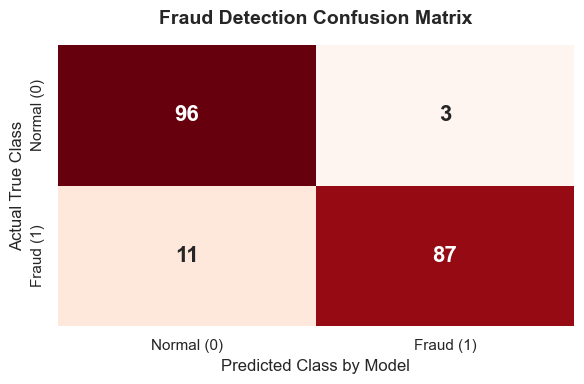

In [20]:
# 8. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.set_theme(style="white")
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, 
            xticklabels=['Normal (0)', 'Fraud (1)'], 
            yticklabels=['Normal (0)', 'Fraud (1)'],
            annot_kws={"size": 16, "weight": "bold"})

plt.title('Fraud Detection Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Class by Model', fontsize=12)
plt.ylabel('Actual True Class', fontsize=12)
plt.tight_layout()
plt.show()